In [1]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

Saving intern_performance.csv to intern_performance.csv


In [2]:
# Load dataset
df = pd.read_csv("intern_performance.csv")

# Show first 5 rows
df.head()

,Intern Name,Task Assigned,Task Completed,Quality Score,Feedback Score
0,Sara,2026-02-02,2026-02-08,7,3
1,Ayesha,2026-02-09,2026-02-15,5,5
2,Zain,2026-02-06,2026-02-11,8,3
3,Ali,2026-02-06,2026-02-08,6,5
4,Noor,2026-02-02,2026-02-07,6,5


In [3]:
# KPI 1 Task Completion Time

# Convert columns to datetime
df['Task Assigned'] = pd.to_datetime(df['Task Assigned'])
df['Task Completed'] = pd.to_datetime(df['Task Completed'])

# Create Completion Time column
df['Completion Time (days)'] = (df['Task Completed'] - df['Task Assigned']).dt.days

df.head()

,Intern Name,Task Assigned,Task Completed,Quality Score,Feedback Score,Completion Time (days)
0,Sara,2026-02-02,2026-02-08,7,3,6
1,Ayesha,2026-02-09,2026-02-15,5,5,6
2,Zain,2026-02-06,2026-02-11,8,3,5
3,Ali,2026-02-06,2026-02-08,6,5,2
4,Noor,2026-02-02,2026-02-07,6,5,5


In [4]:
# KPI 2: Project Quality
# Categorize Quality
def quality_label(score):
    if score >= 9:
        return "Excellent"
    elif score >= 7:
        return "Good"
    elif score >= 5:
        return "Average"
    else:
        return "Poor"

df['Quality Category'] = df['Quality Score'].apply(quality_label)

In [5]:
#Mentor Feedback
# Categorize Feedback
def feedback_label(score):
    if score == 5:
        return "Outstanding"
    elif score == 4:
        return "Good"
    elif score == 3:
        return "Average"
    else:
        return "Needs Improvement"

df['Feedback Category'] = df['Feedback Score'].apply(feedback_label)

In [6]:
# Automating Monthly Reports
#Extract Month
df['Month'] = df['Task Completed'].dt.to_period('M')

#Monthly KPI Report
monthly_report = df.groupby('Month').agg({
    'Completion Time (days)': 'mean',
    'Quality Score': 'mean',
    'Feedback Score': 'mean'
}).reset_index()

monthly_report.columns = [
    'Month',
    'Avg Completion Time',
    'Avg Quality Score',
    'Avg Feedback Score'
]

monthly_report

#Adding Performance Insight per month
def performance_status(row):
    if row['Avg Quality Score'] >= 8 and row['Avg Feedback Score'] >= 4:
        return "High Performance"
    elif row['Avg Quality Score'] >= 6:
        return "Moderate Performance"
    else:
        return "Needs Improvement"

monthly_report['Performance Status'] = monthly_report.apply(performance_status, axis=1)

monthly_report

#Saving automated report
monthly_report.to_csv("monthly_performance_report.csv", index=False)

from google.colab import files
files.download("monthly_performance_report.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
import matplotlib.pyplot as plt

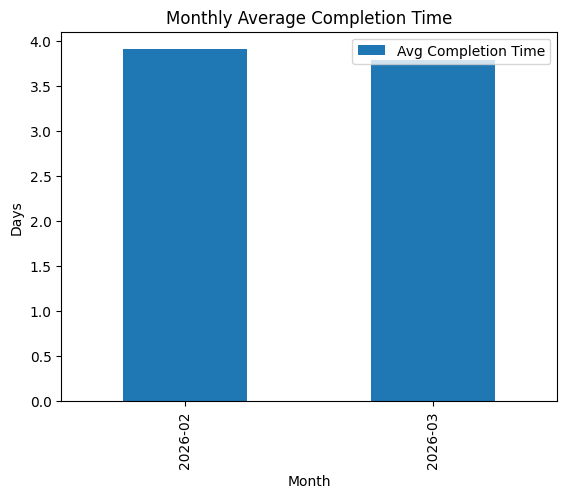

In [8]:
# Chart 1: Monthly Average Completion Time

monthly_report.plot(x='Month', y='Avg Completion Time', kind='bar')

plt.title("Monthly Average Completion Time")
plt.xlabel("Month")
plt.ylabel("Days")

plt.show()

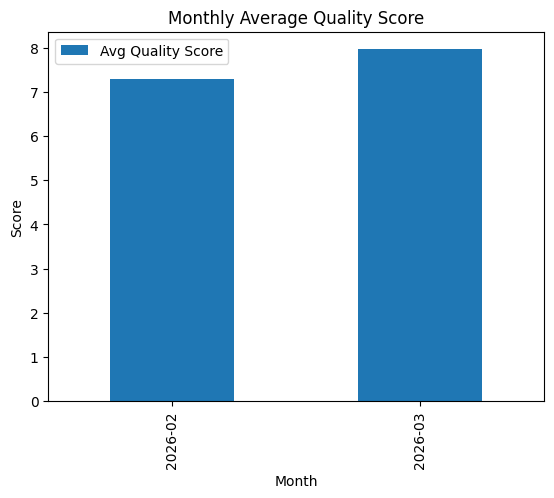

In [9]:
# Chart 2: Monthly Quality Score

monthly_report.plot(x='Month', y='Avg Quality Score', kind='bar')

plt.title("Monthly Average Quality Score")
plt.xlabel("Month")
plt.ylabel("Score")

plt.show()

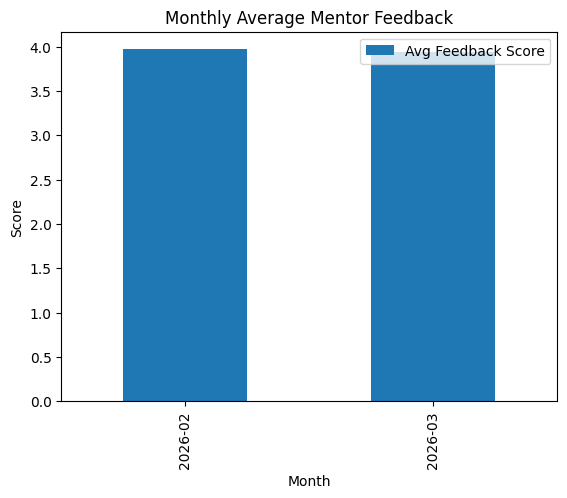

In [10]:
#Chart 3: Monthly Feedback Score
monthly_report.plot(x='Month', y='Avg Feedback Score', kind='bar')

plt.title("Monthly Average Mentor Feedback")
plt.xlabel("Month")
plt.ylabel("Score")

plt.show()